In [1]:
!mamba install pandas numpy matplotlib seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.19179999999702 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2      

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

['Intro.ipynb',
 'Untitled11.ipynb',
 'Untitled12.ipynb',
 'googleplaystore - googleplaystore.csv',
 'sqlite.ipynb',
 'r.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']

In [66]:
import pandas as pd

df = pd.read_csv("googleplaystore - googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
# Check for missing values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
# Drop rows with missing values in important columns
df.dropna(subset=['Rating', 'Reviews', 'Size', 'Installs'],
inplace=True)

In [13]:
# Check the updated data
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   str    
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   str    
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), str(12)
memory usage: 585.4 KB


In [15]:
# Convert Reviews column to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Replace NaN with 0 and convert to integer
df['Reviews'] = df['Reviews'].fillna(0).astype(int)

In [16]:
df.info()
df['Reviews'].head()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   str    
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), int32(1), str(11)
memory usage: 585.4 KB


0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: int32

In [19]:
# Remove commas and +
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')

# Convert to numeric safely
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [20]:
df['Installs'] = df['Installs'].fillna(0).astype(int)

In [22]:
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '').str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'] = df['Installs'].fillna(0).astype(int)

In [23]:
df['Installs'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), int32(2), str(10)
memory usage: 585.4 KB


In [25]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'] = df['Price'].fillna(0)

In [26]:
df['Price'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   float64
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(2), int32(2), str(9)
memory usage: 622.0 KB


In [28]:
# Convert 'Size' to numeric (MB)
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1000
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)



In [29]:
df['Size'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            7729 non-null   float64
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   float64
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(3), int32(2), str(8)
memory usage: 658.6 KB


In [30]:
# Check for duplicates
df.duplicated().sum()

np.int64(474)

In [31]:
# Remove duplicates
df.drop_duplicates(inplace=True)


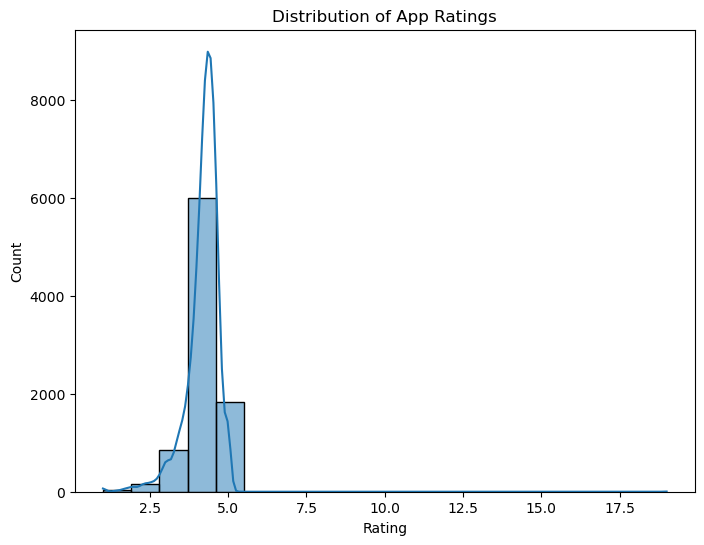

In [32]:
plt.figure(figsize=(8,6))
sns.histplot(df['Rating'].dropna(), bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Category'>

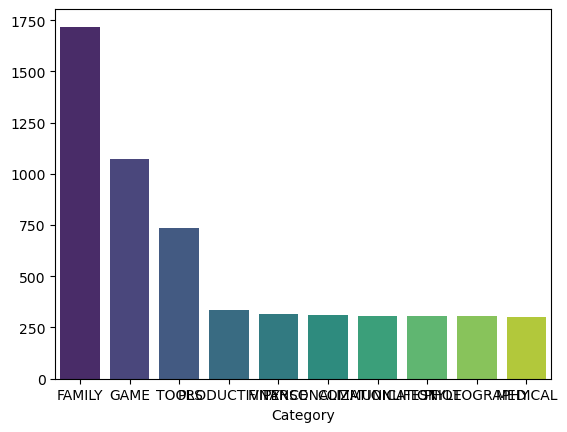

In [34]:
sns.barplot(
    x=top_categories.index,
    y=top_categories.values,
    hue=top_categories.index,
    palette='viridis',
    legend=False
)

<Axes: xlabel='Type', ylabel='count'>

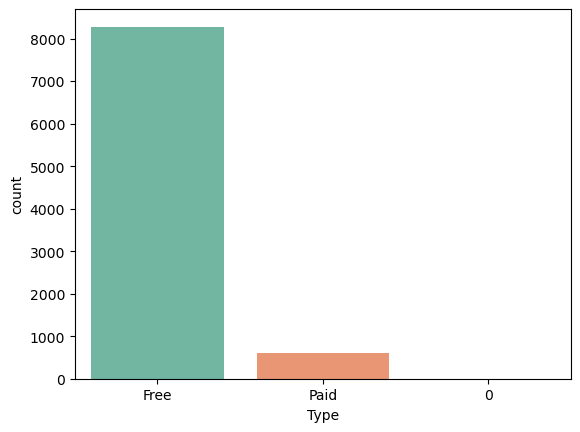

In [36]:
sns.countplot(x='Type', data=df, hue='Type', palette='Set2', legend=False)

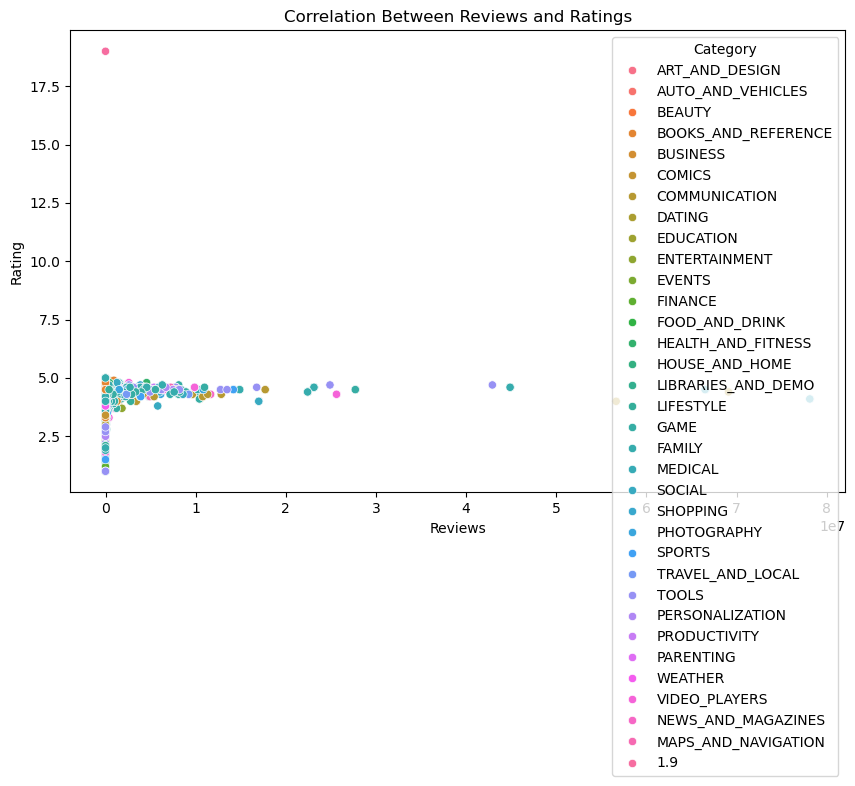

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Reviews', y='Rating', data=df, hue='Category')
plt.title('Correlation Between Reviews and Ratings')
plt.show()

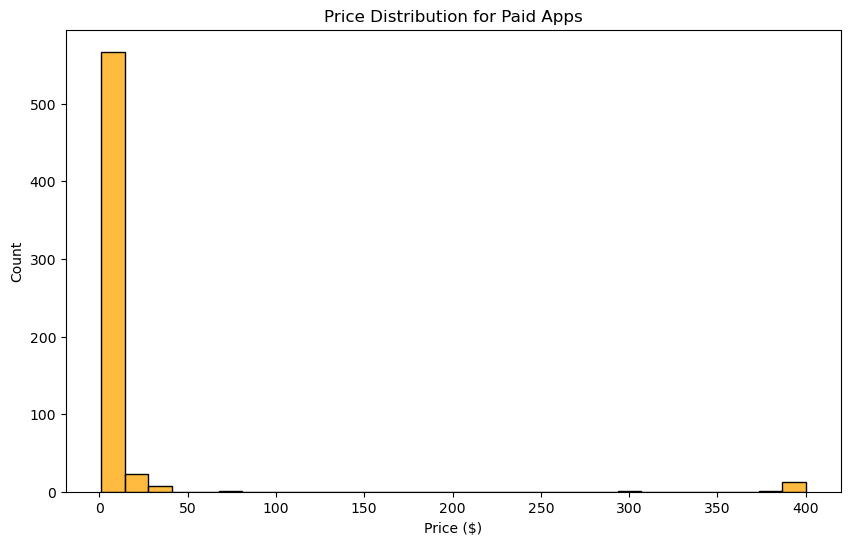

In [38]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

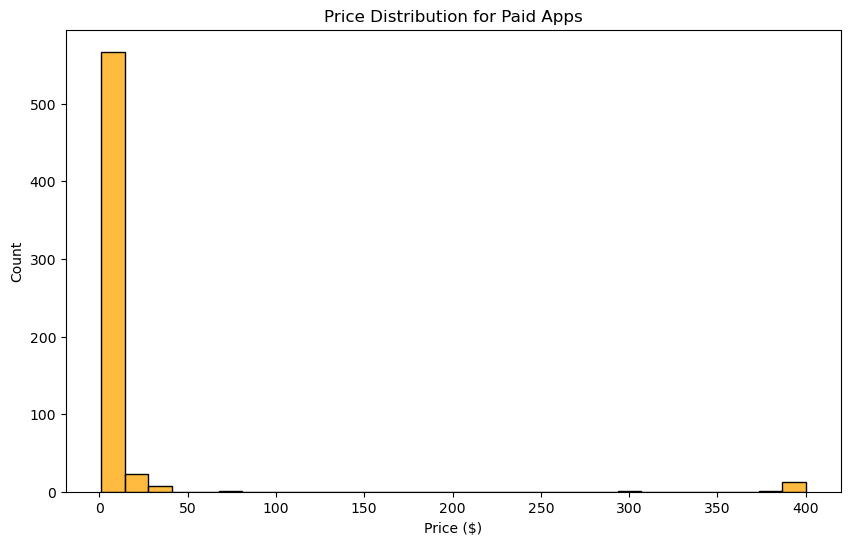

In [39]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

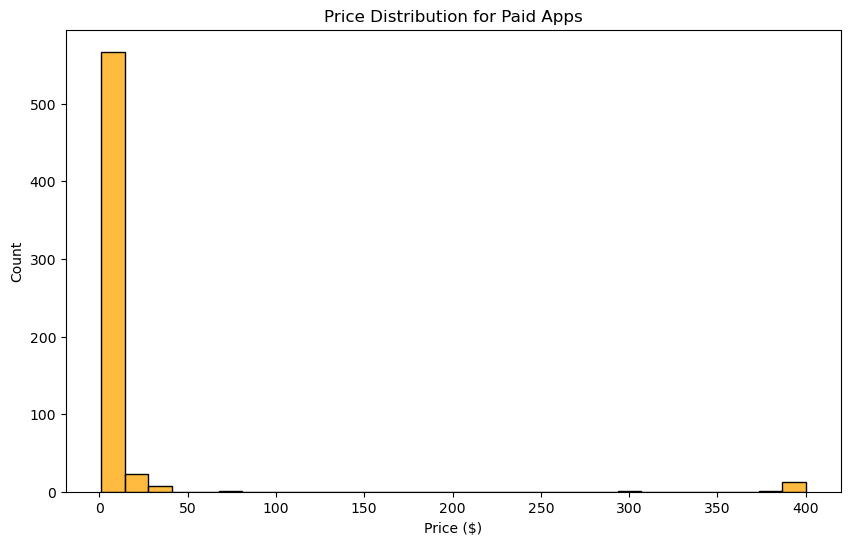

In [40]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

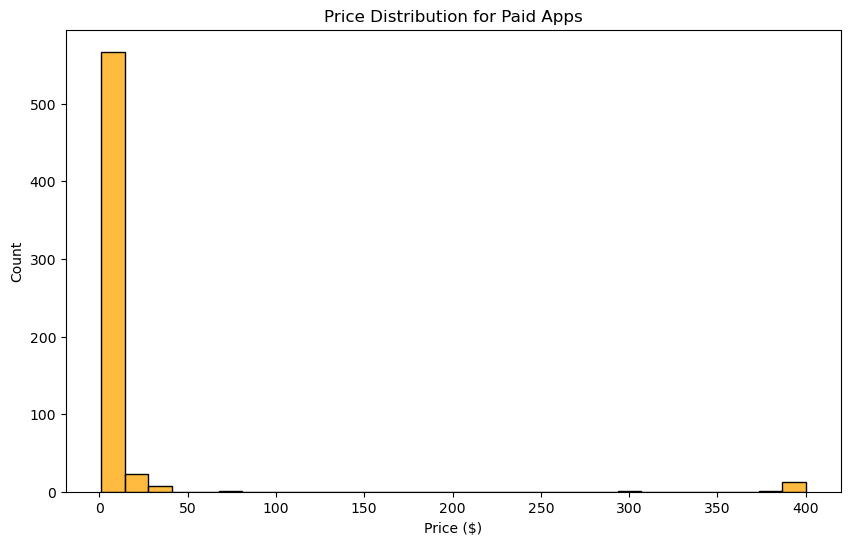

In [41]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

In [44]:
top_genres_installs = df.groupby('Genres')['Installs'].sum().sort_values(ascending=False).head(10)

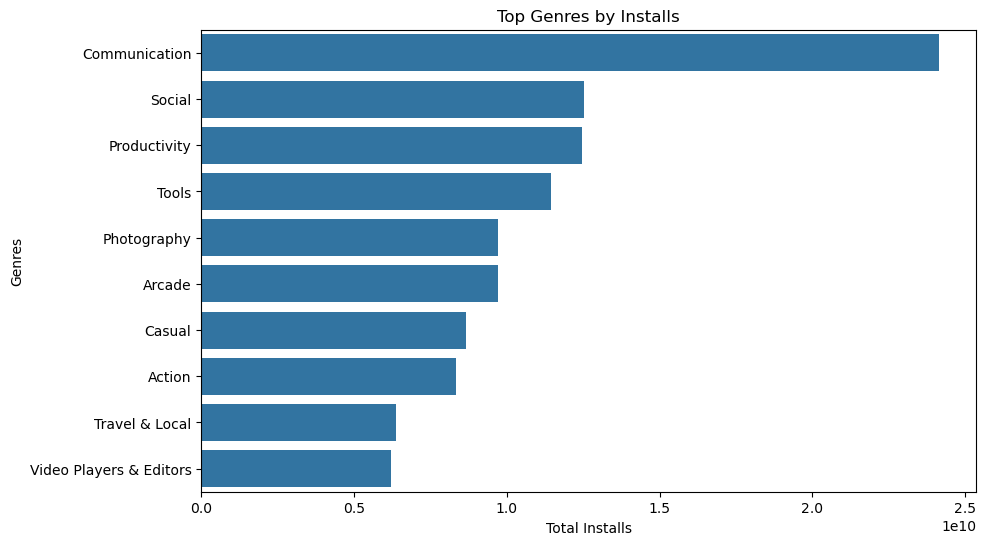

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres_installs.values, y=top_genres_installs.index)

plt.title("Top Genres by Installs")
plt.xlabel("Total Installs")
plt.ylabel("Genres")

plt.show()

In [ ]:
!pip install scikit-learn

mambajs 0.19.13

Process pip requirements ...



Cannot install 'scikit-learn' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install scikit-learn" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [48]:
!mamba install scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.6312000000029803 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.5                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                    

In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])
df['Content Rating'] = label_encoder.fit_transform(df['Content Rating'])
df['Category'] = label_encoder.fit_transform(df['Category'])

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 8893 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8893 non-null   str    
 1   Category        8893 non-null   int32  
 2   Rating          8893 non-null   float64
 3   Reviews         8893 non-null   int32  
 4   Size            7424 non-null   float64
 5   Installs        8893 non-null   int32  
 6   Type            8893 non-null   int32  
 7   Price           8893 non-null   float64
 8   Content Rating  8893 non-null   int32  
 9   Genres          8893 non-null   str    
 10  Last Updated    8893 non-null   str    
 11  Current Ver     8889 non-null   str    
 12  Android Ver     8890 non-null   str    
dtypes: float64(3), int32(5), str(5)
memory usage: 625.3 KB


In [51]:
# Define features and target variable
X = df[['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
'Genres', 'Content Rating']]
y = df['Rating']

In [52]:
# Handle missing values in target
y.fillna(y.median(), inplace=True)

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10834    4.0
10836    4.5
10837    5.0
10839    4.5
10840    4.5
Name: Rating, Length: 8893, dtype: float64

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
X = df.drop(['Rating','App','Genres','Last Updated','Current Ver','Android Ver'], axis=1)
y = df['Rating']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [60]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [61]:
predictions = model.predict(X_test)

from sklearn.metrics import r2_score
print("Model Score:", r2_score(y_test, predictions))

Model Score: 0.12365042172919516


In [62]:
# Make predictions
y_pred = model.predict(X_test)

In [63]:
# Evaluate the model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [64]:
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.2476784795507454
R-squared: 0.12365042172919516


In [1]:
!mamba install pandas numpy matplotlib seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.19179999999702 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2      

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

['Intro.ipynb',
 'Untitled11.ipynb',
 'Untitled12.ipynb',
 'googleplaystore - googleplaystore.csv',
 'sqlite.ipynb',
 'r.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']

In [66]:
import pandas as pd

df = pd.read_csv("googleplaystore - googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
# Check for missing values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [12]:
# Drop rows with missing values in important columns
df.dropna(subset=['Rating', 'Reviews', 'Size', 'Installs'],
inplace=True)

In [13]:
# Check the updated data
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   str    
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   str    
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), str(12)
memory usage: 585.4 KB


In [15]:
# Convert Reviews column to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Replace NaN with 0 and convert to integer
df['Reviews'] = df['Reviews'].fillna(0).astype(int)

In [16]:
df.info()
df['Reviews'].head()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   str    
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), int32(1), str(11)
memory usage: 585.4 KB


0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: int32

In [19]:
# Remove commas and +
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')

# Convert to numeric safely
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [20]:
df['Installs'] = df['Installs'].fillna(0).astype(int)

In [22]:
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '').str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'] = df['Installs'].fillna(0).astype(int)

In [23]:
df['Installs'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   str    
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(1), int32(2), str(10)
memory usage: 585.4 KB


In [25]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'] = df['Price'].fillna(0)

In [26]:
df['Price'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            9367 non-null   str    
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   float64
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(2), int32(2), str(9)
memory usage: 622.0 KB


In [28]:
# Convert 'Size' to numeric (MB)
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1000
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)



In [29]:
df['Size'].head()
df.info()

<class 'pandas.DataFrame'>
Index: 9367 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9367 non-null   str    
 1   Category        9367 non-null   str    
 2   Rating          9367 non-null   float64
 3   Reviews         9367 non-null   int32  
 4   Size            7729 non-null   float64
 5   Installs        9367 non-null   int32  
 6   Type            9367 non-null   str    
 7   Price           9367 non-null   float64
 8   Content Rating  9366 non-null   str    
 9   Genres          9367 non-null   str    
 10  Last Updated    9367 non-null   str    
 11  Current Ver     9363 non-null   str    
 12  Android Ver     9364 non-null   str    
dtypes: float64(3), int32(2), str(8)
memory usage: 658.6 KB


In [30]:
# Check for duplicates
df.duplicated().sum()

np.int64(474)

In [31]:
# Remove duplicates
df.drop_duplicates(inplace=True)


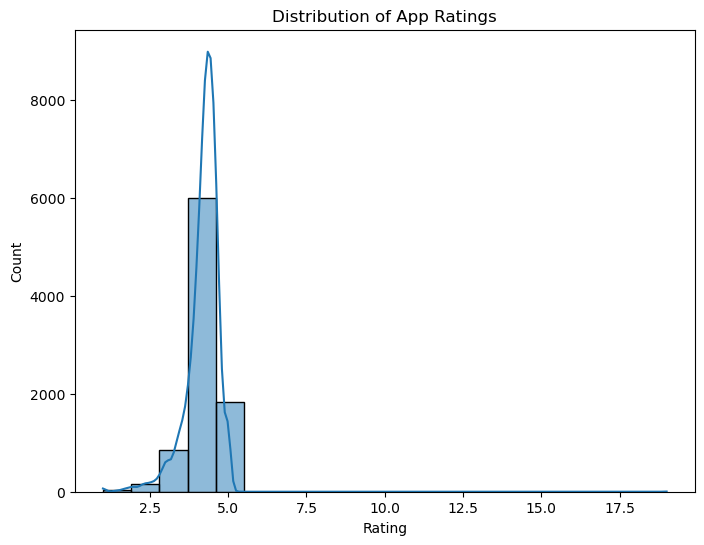

In [32]:
plt.figure(figsize=(8,6))
sns.histplot(df['Rating'].dropna(), bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Category'>

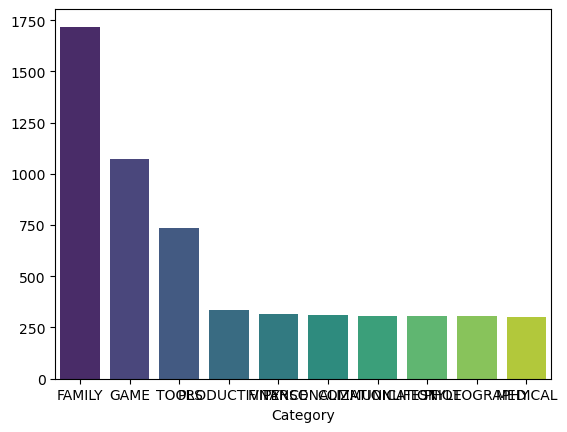

In [34]:
sns.barplot(
    x=top_categories.index,
    y=top_categories.values,
    hue=top_categories.index,
    palette='viridis',
    legend=False
)

<Axes: xlabel='Type', ylabel='count'>

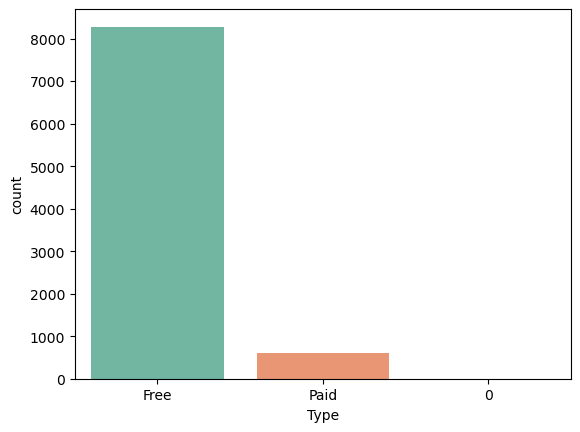

In [36]:
sns.countplot(x='Type', data=df, hue='Type', palette='Set2', legend=False)

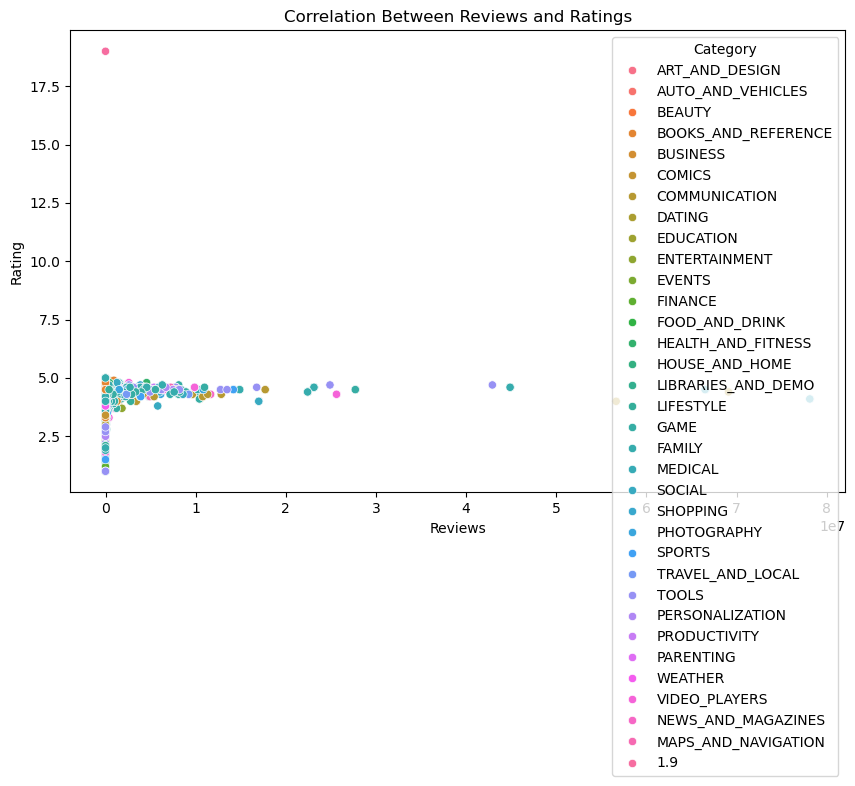

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Reviews', y='Rating', data=df, hue='Category')
plt.title('Correlation Between Reviews and Ratings')
plt.show()

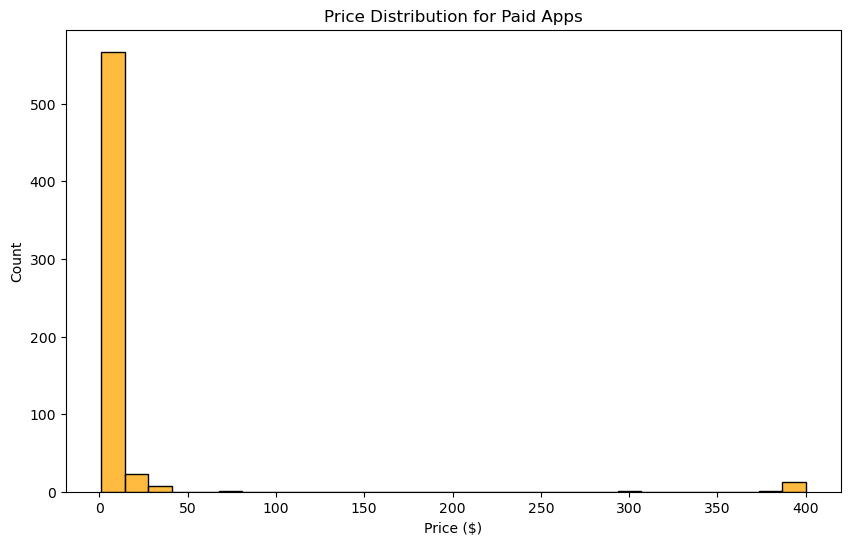

In [38]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

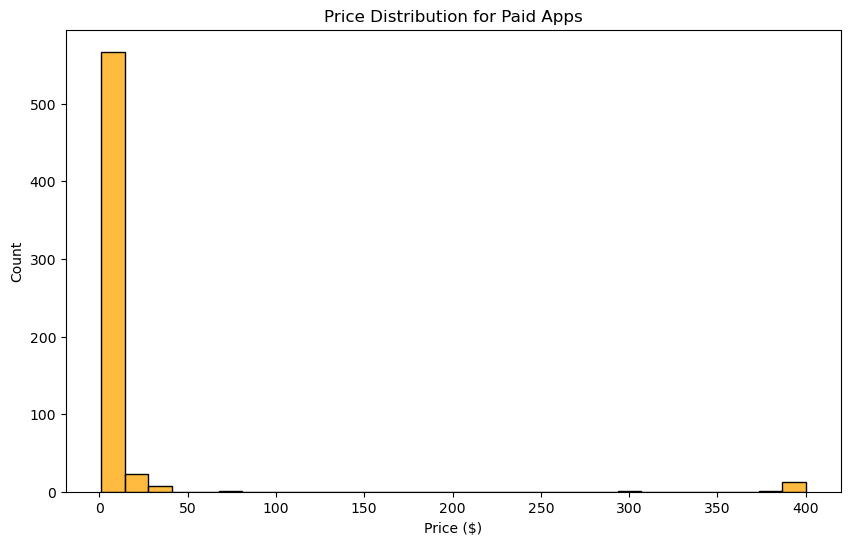

In [39]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

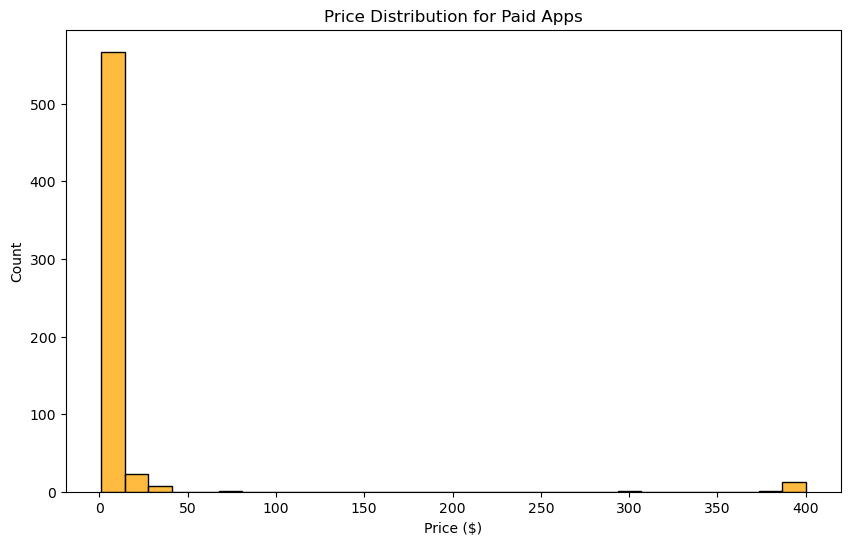

In [40]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

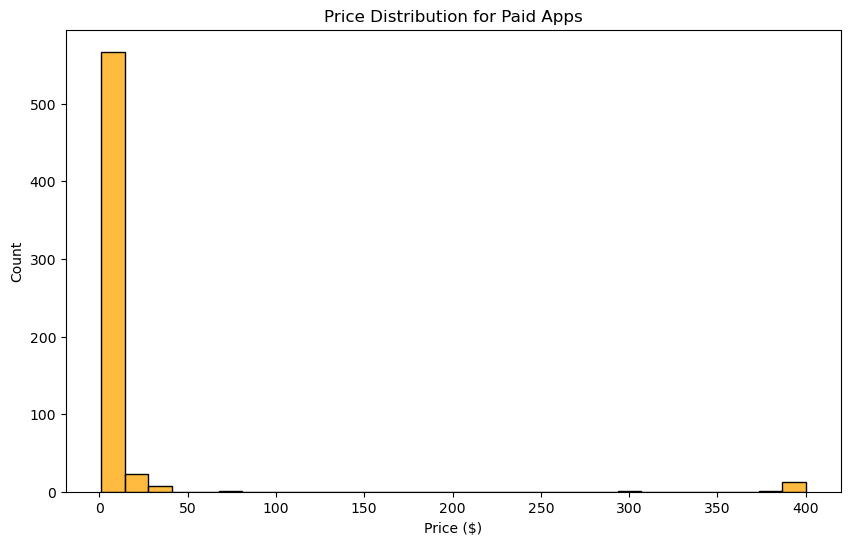

In [41]:
paid_apps = df[df['Type'] == 'Paid']
plt.figure(figsize=(10,6))
sns.histplot(paid_apps['Price'], bins=30, color='orange')
plt.title('Price Distribution for Paid Apps')

plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

In [44]:
top_genres_installs = df.groupby('Genres')['Installs'].sum().sort_values(ascending=False).head(10)

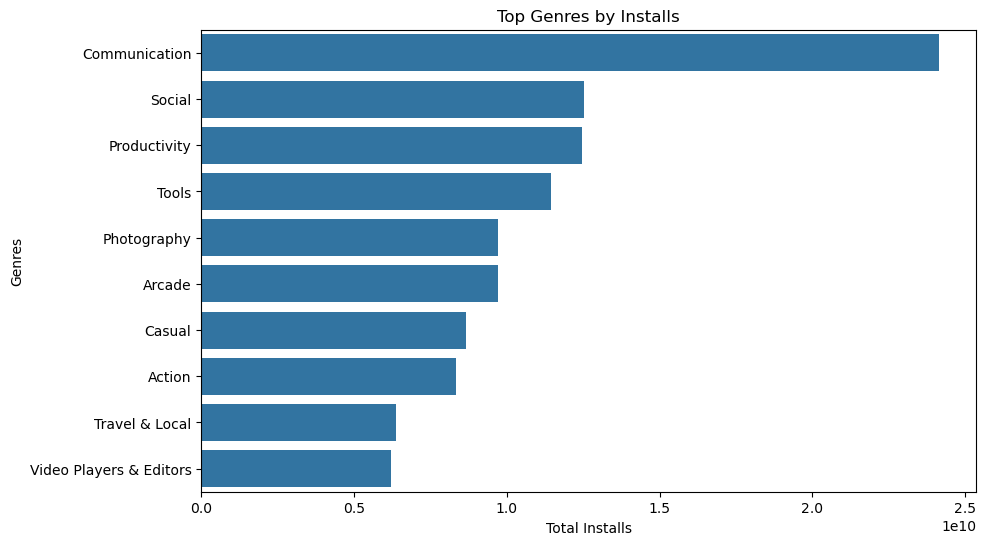

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres_installs.values, y=top_genres_installs.index)

plt.title("Top Genres by Installs")
plt.xlabel("Total Installs")
plt.ylabel("Genres")

plt.show()

In [ ]:
!pip install scikit-learn

mambajs 0.19.13

Process pip requirements ...



Cannot install 'scikit-learn' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install scikit-learn" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [48]:
!mamba install scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.6312000000029803 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.5                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                    

In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])
df['Content Rating'] = label_encoder.fit_transform(df['Content Rating'])
df['Category'] = label_encoder.fit_transform(df['Category'])

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 8893 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8893 non-null   str    
 1   Category        8893 non-null   int32  
 2   Rating          8893 non-null   float64
 3   Reviews         8893 non-null   int32  
 4   Size            7424 non-null   float64
 5   Installs        8893 non-null   int32  
 6   Type            8893 non-null   int32  
 7   Price           8893 non-null   float64
 8   Content Rating  8893 non-null   int32  
 9   Genres          8893 non-null   str    
 10  Last Updated    8893 non-null   str    
 11  Current Ver     8889 non-null   str    
 12  Android Ver     8890 non-null   str    
dtypes: float64(3), int32(5), str(5)
memory usage: 625.3 KB


In [51]:
# Define features and target variable
X = df[['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
'Genres', 'Content Rating']]
y = df['Rating']

In [52]:
# Handle missing values in target
y.fillna(y.median(), inplace=True)

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10834    4.0
10836    4.5
10837    5.0
10839    4.5
10840    4.5
Name: Rating, Length: 8893, dtype: float64

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
X = df.drop(['Rating','App','Genres','Last Updated','Current Ver','Android Ver'], axis=1)
y = df['Rating']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [60]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [61]:
predictions = model.predict(X_test)

from sklearn.metrics import r2_score
print("Model Score:", r2_score(y_test, predictions))

Model Score: 0.12365042172919516


In [62]:
# Make predictions
y_pred = model.predict(X_test)

In [63]:
# Evaluate the model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [64]:
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.2476784795507454
R-squared: 0.12365042172919516
